Problem definition a) start b)initial solution c) final solution 


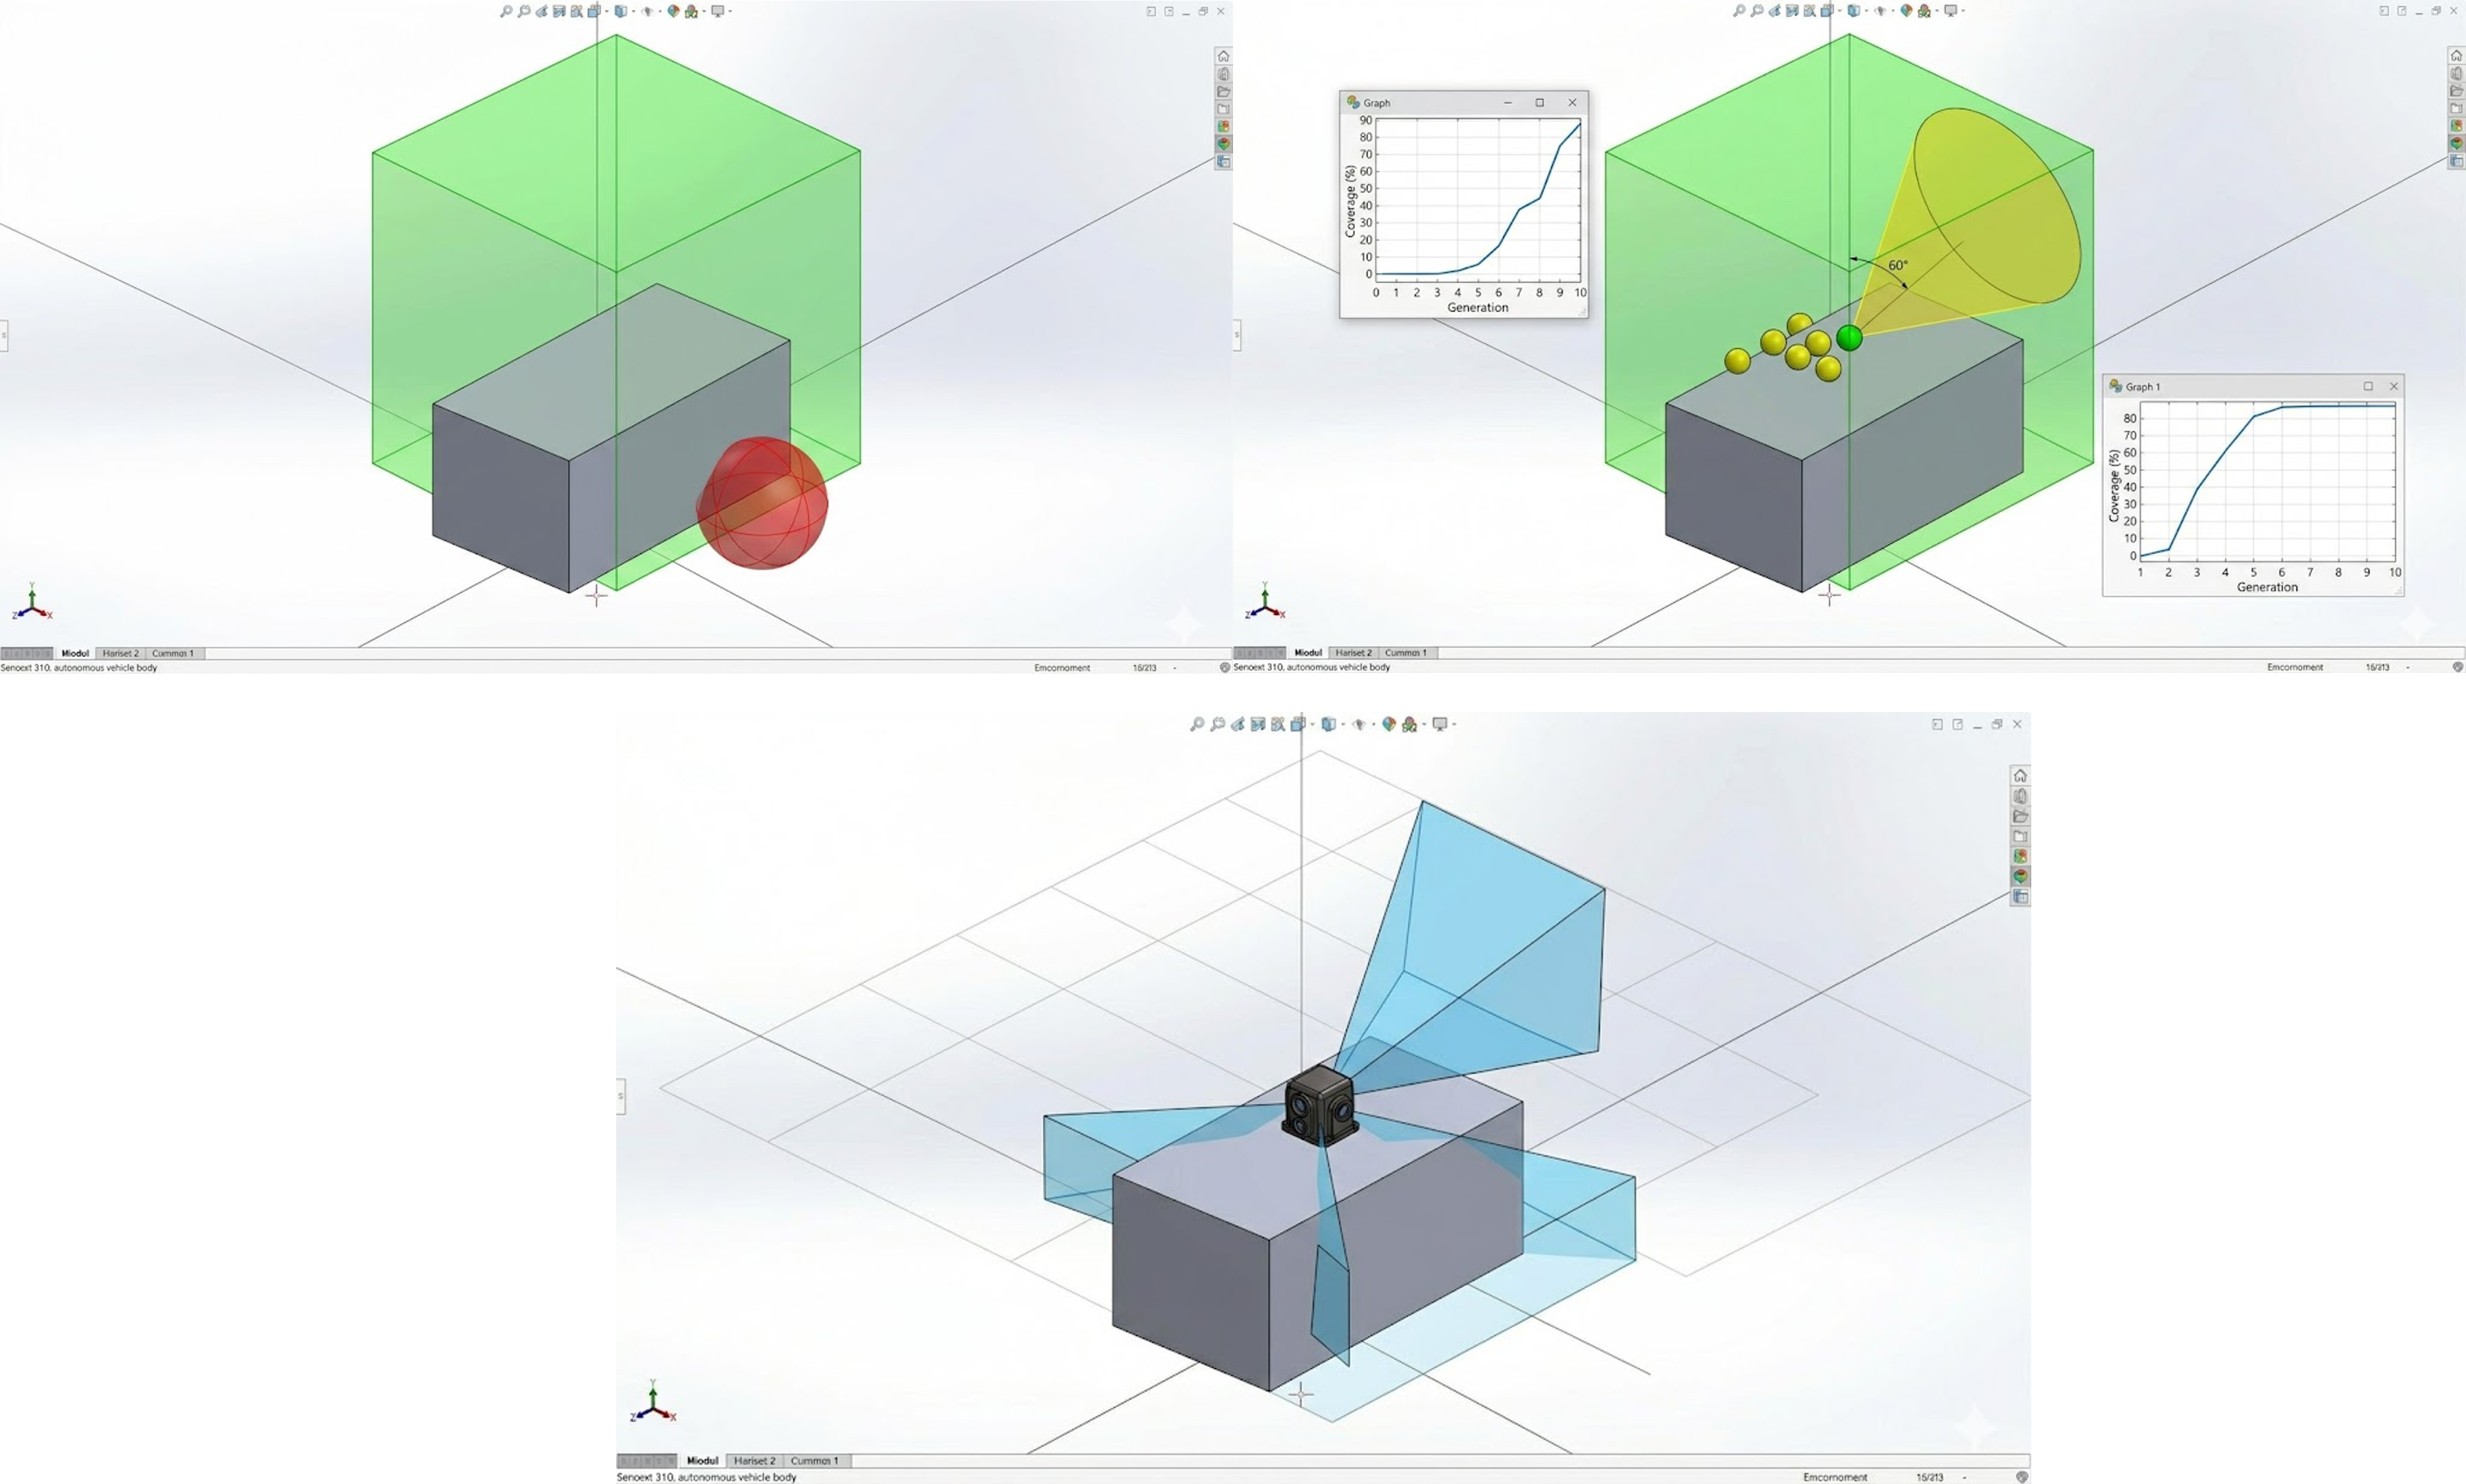

Camera Frustum camera 


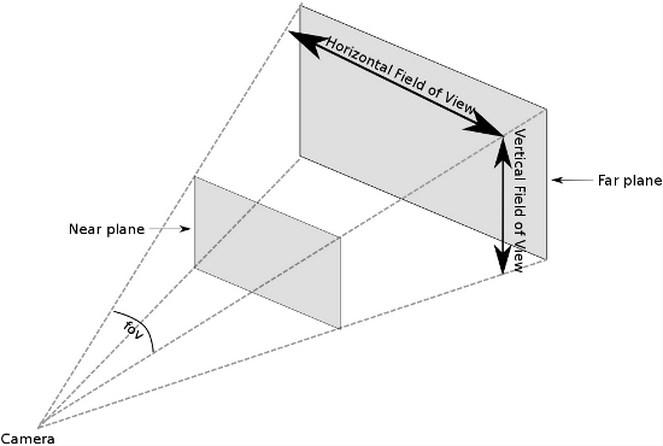

Redundency


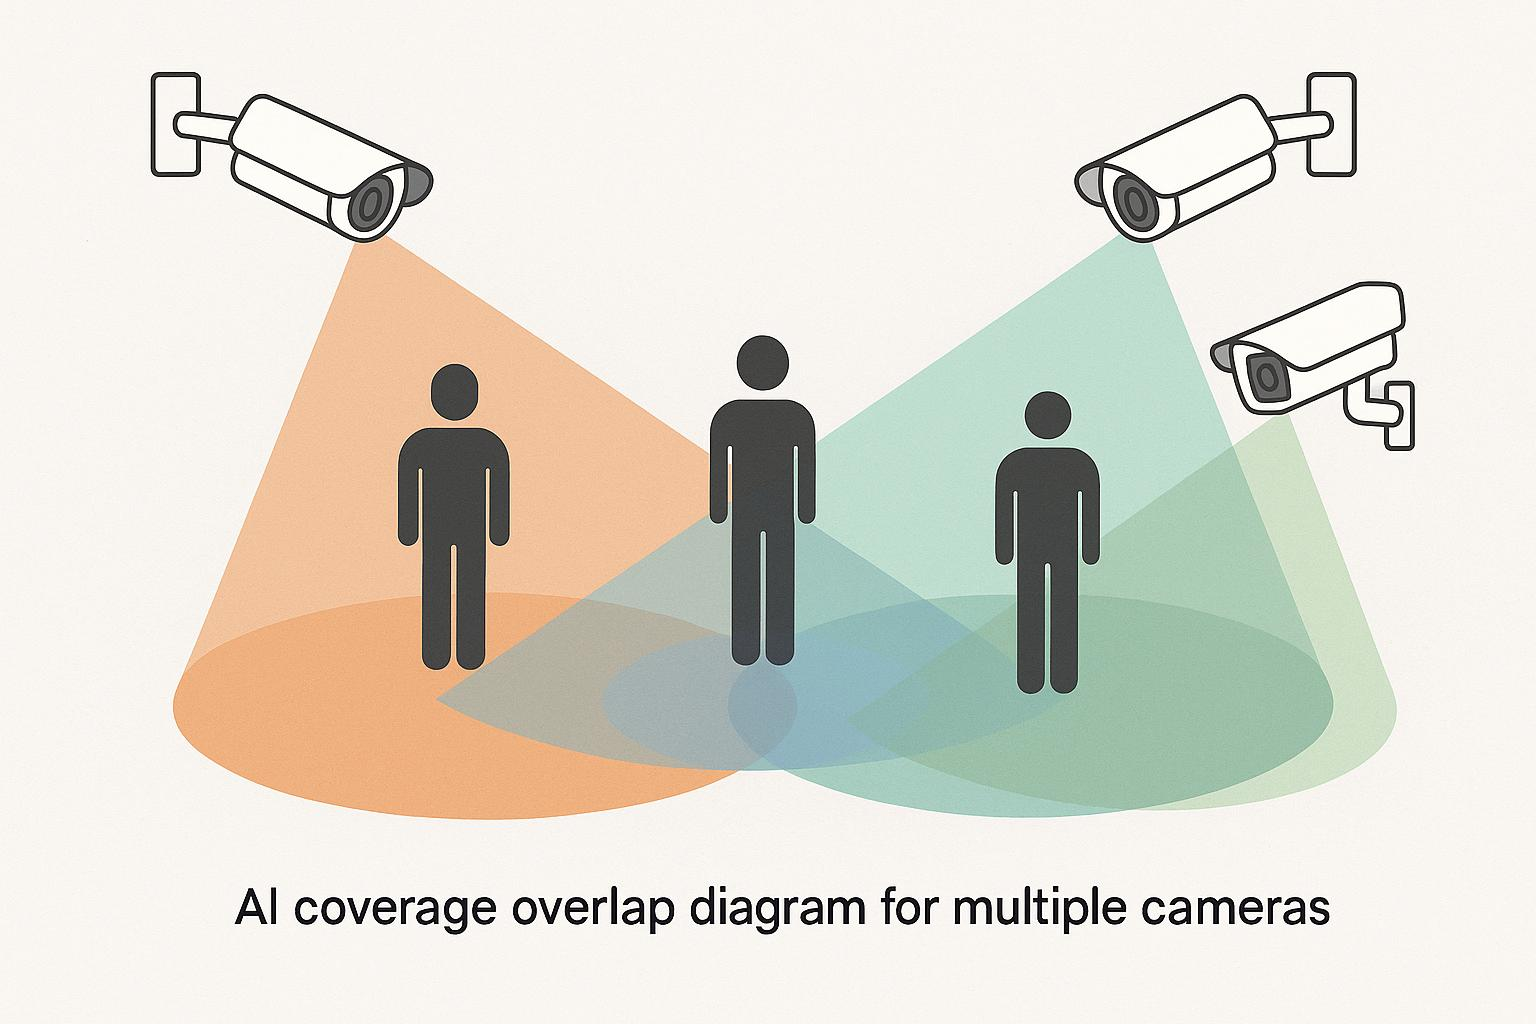

In [52]:
from IPython.display import Image, display
print ("Problem definition a) start b)initial solution c) final solution ")
#update your path here
display(Image(filename="C:\\Users\\ANT-PC\\Downloads\\GA.png"))

print ("Camera Frustum camera ")

display(Image(filename="C:\\Users\\ANT-PC\\Downloads\\frustum.jpeg"))

print ("Redundency")

display(Image(filename="C:\\Users\\ANT-PC\\Downloads\\overlap.jpeg"))

------------------------------------------------------------
3D CAMERA PLACEMENT OPTIMIZATION - CORE IMPLEMENTATION
============================================================

This code implements the mathematical formulation:

    Fitness = Coverage + λ × Redundancy − Penalty

Each component corresponds to a physical interpretation:
- Coverage   → how much environment is visible
- Redundancy → how well it is observed (multi-view)
- Penalty    → whether solution is physically valid

------------------------------------------------------------
IMPORTANT VARIABLES (GLOBAL PARAMETERS)
------------------------------------------------------------

vehicle_length, vehicle_width, vehicle_height:
    Define the physical bounds of the vehicle

num_cameras:
    Number of cameras to optimize
    ↑ Increasing → better coverage but higher redundancy

fov_h, fov_v:
    Horizontal and vertical field of view
    ↑ Larger FOV → more coverage but less precision

max_range:
    Maximum sensing distance of camera

points:
    Discretized 3D environment (voxels)

------------------------------------------------------------
KEY IDEA
------------------------------------------------------------

Each candidate solution = set of cameras:
    [x, y, z, yaw, pitch]

We evaluate how good this configuration is.



## Mathematical Formulation

Let:

- P = set of all 3D environment points  
- V(p) = number of cameras that see point p  

### Coverage

Coverage = |{p ∈ P : V(p) ≥ 1}| / |P|

→ Fraction of visible space
| Point | Cameras seeing it | V(p) |
| ----- | ----------------- | ---- |
| p1    | 1 camera          | 1    |
| p2    | 2 cameras         | 2    |
| p3    | 0 cameras         | 0    |
| p4    | 1 camera          | 1    |
| p5    | 0 cameras         | 0    |
| p6    | 3 cameras         | 3    |
| p7    | 1 camera          | 1    |
| p8    | 0 cameras         | 0    |
| p9    | 1 camera          | 1    |
| p10   | 0 cameras         | 0    |
Count visible points:

Points with 𝑉(𝑝)≥1 : p1, p2, p4, p6, p7, p9 → 6 points Coverage=6/10=0.6


### Redundancy

Redundancy = (Σ V(p)) / |P|

∑p∈PV(p), means:Add up how many times ALL points are seen

| Point | Cameras seeing it | ( V(p) ) |
| ----- | ----------------- | -------- |
| p1    | 1 camera          | 1        |
| p2    | 2 cameras         | 2        |
| p3    | 0 cameras         | 0        |
| p4    | 1 camera          | 1        |
| p5    | 0 cameras         | 0        |
| p6    | 3 cameras         | 3        |
| p7    | 1 camera          | 1        |
| p8    | 0 cameras         | 0        |
| p9    | 1 camera          | 1        |
| p10   | 0 cameras         | 0        |

Sum all values/Divide by total points = 9/10

---

### Penalty

Penalty = number of constraint violations

Examples:
- Camera outside vehicle
- Invalid height

---

### Final Objective

Fitness = Coverage + λ × Redundancy − Penalty


## Key Observations

- If coverage increases → system sees more area
- If redundancy increases → system becomes more robust
- If penalty increases → solution is physically invalid

---

## Important Insight

The fitness function defines:
    What the system learns

Bad fitness → bad optimization

---

## Try This

1. Set λ = 0
   → observe loss of redundancy
   If λ is small -> will focus on coverage, if λ is large -> Cameras cluster → high overlap

2. Remove penalty
   → cameras move outside vehicle

3. Increase FOV
   → coverage increases, redundancy decreases

4. Increase number of cameras
   → redundancy increases significantly


In [28]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation


In [43]:

# Vehicle dimensions
vehicle_length = 4
vehicle_width = 2
vehicle_height = 2

# Cameras
num_cameras = 3

# Field of view
fov_h = np.deg2rad(60)
fov_v = np.deg2rad(40)
max_range = 6

# GA parameters
pop_size = 20
num_generations = 40
mutation_rate = 0.5
lambda_red = 0.2



In [ ]:
from IPython.display import Image, display
print ("Visibility of a Point")
display(Image(filename="C:\\Users\\ANT-PC\\Downloads\\Voxel.png"))


A voxel of points 


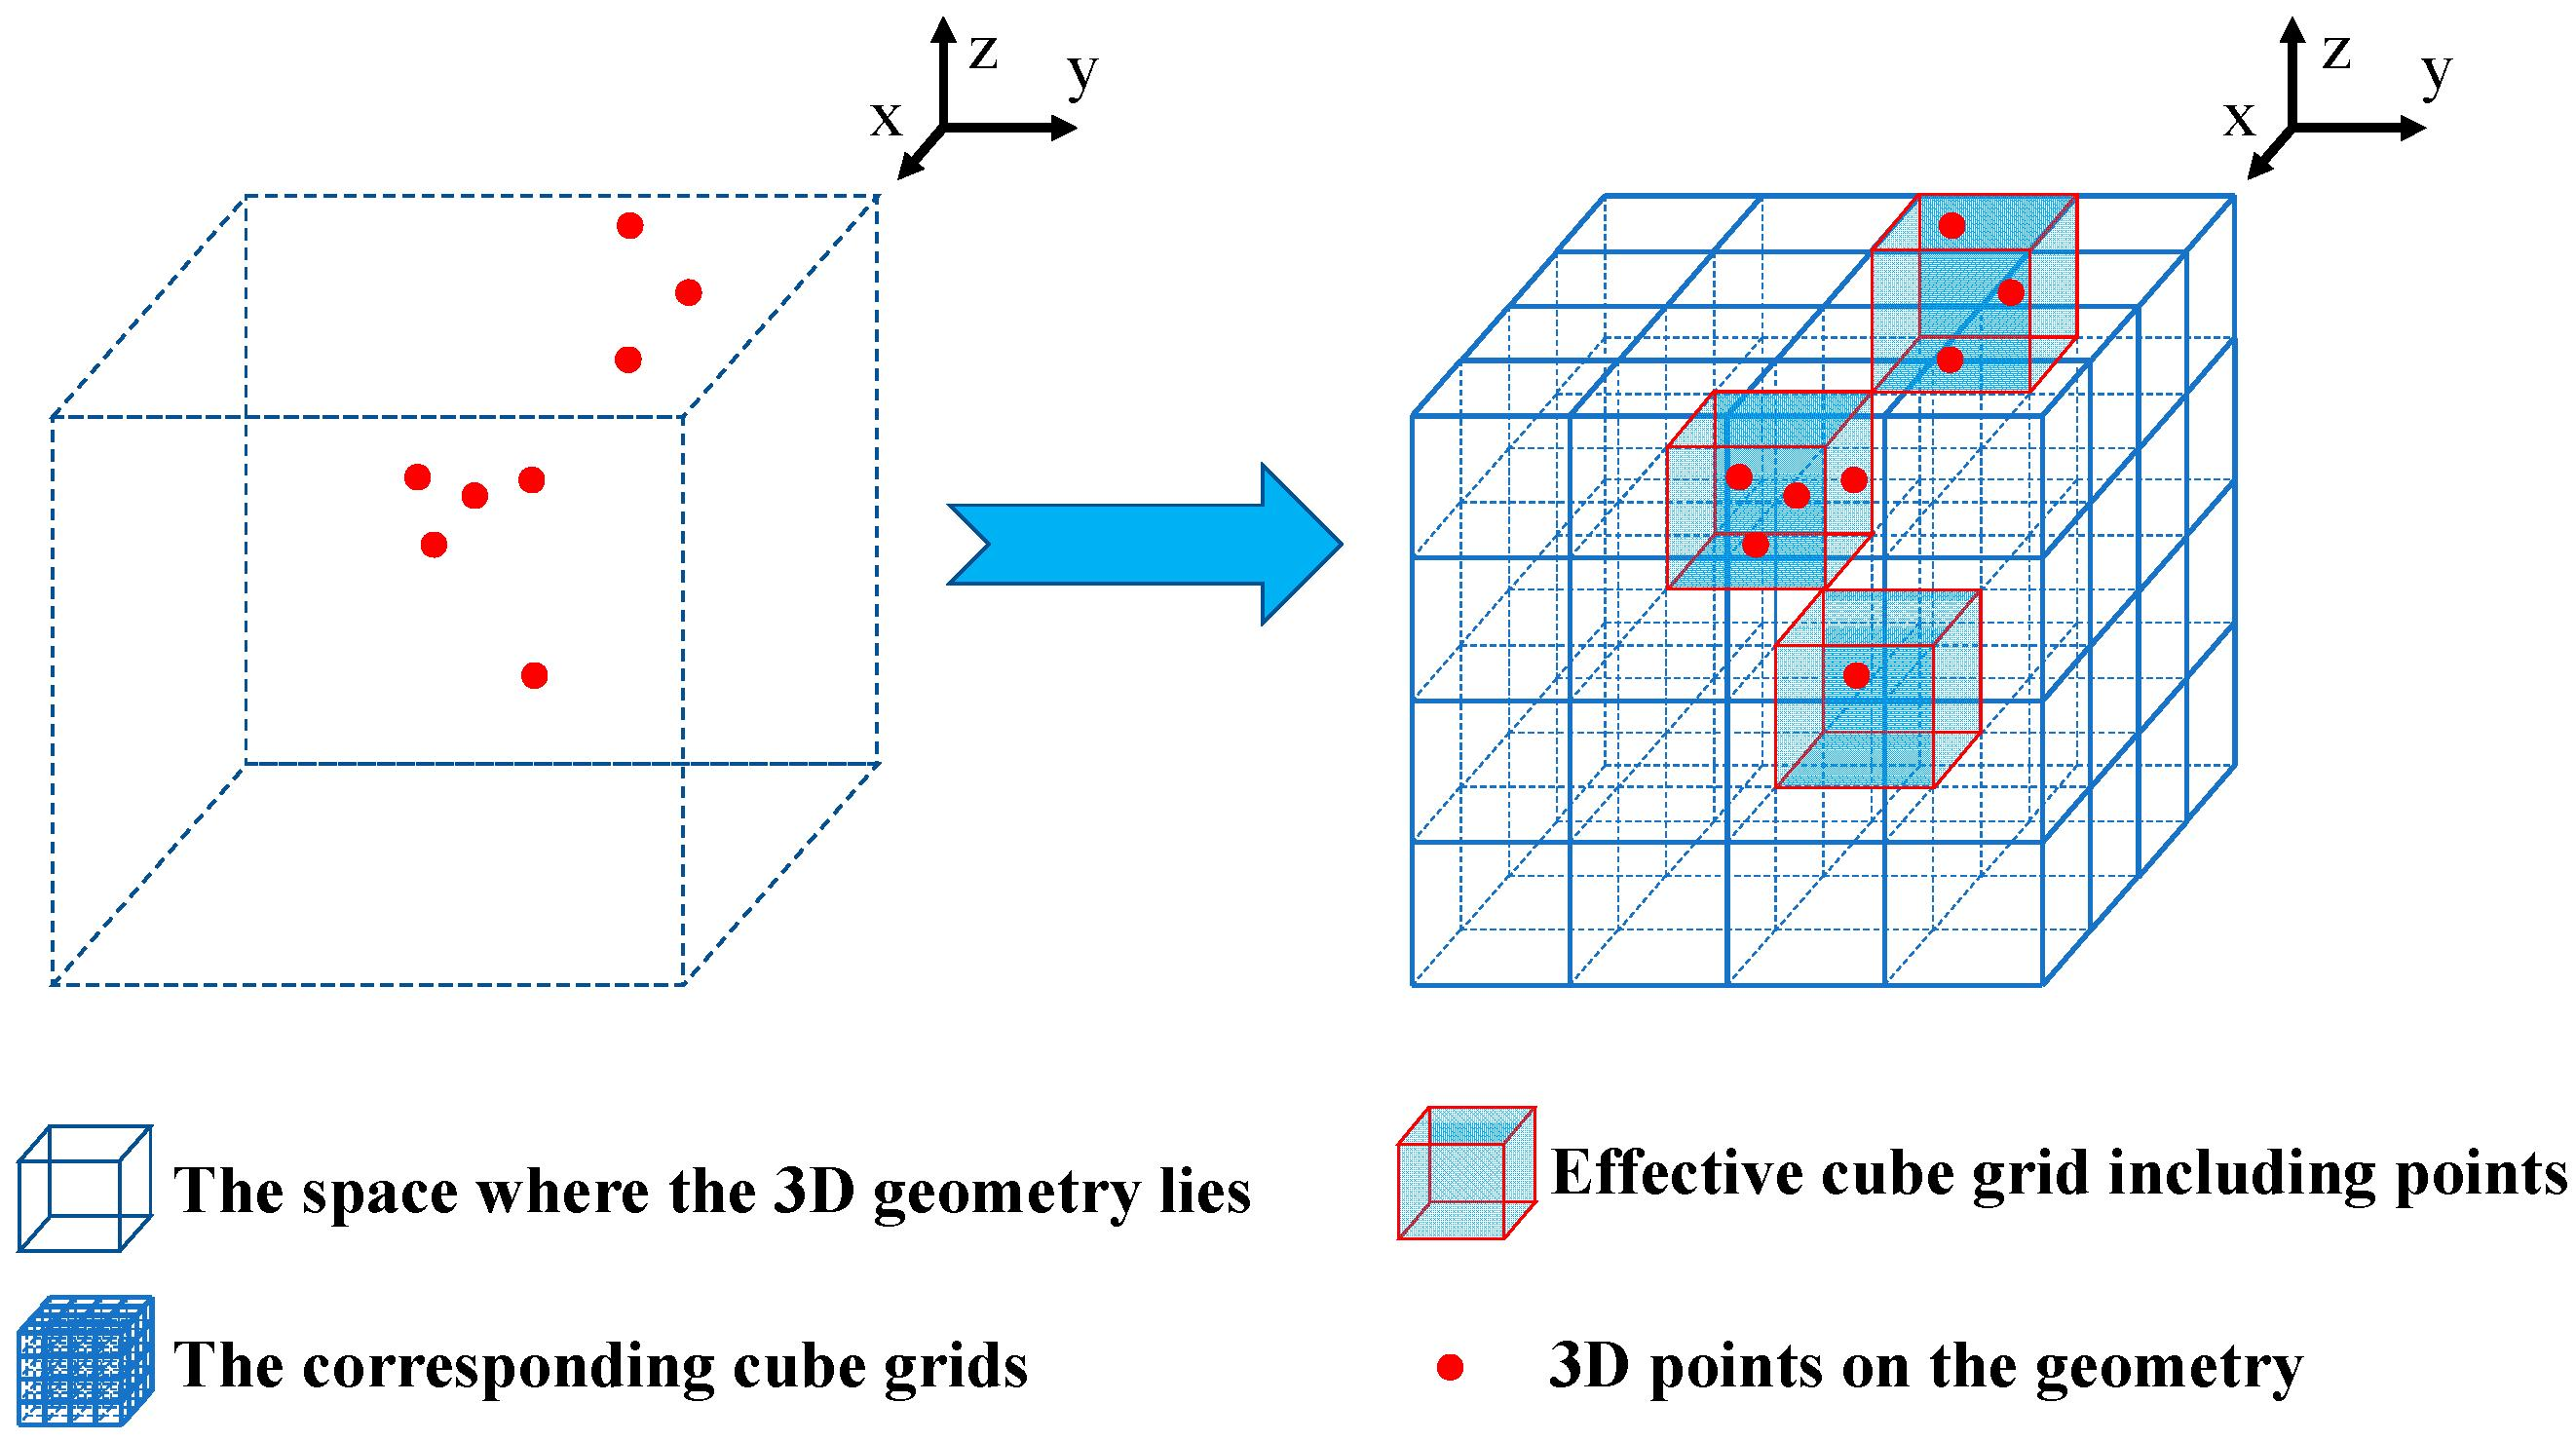

In [54]:

print ("A voxel of points ")
#update your path here
display(Image(filename="C:\\Users\\ANT-PC\\Downloads\\Voxel.jpeg"))



In [ ]:

# Environment grid
grid_size = 25 #(Total points = 25 × 25 × 25 )

#defining a 3D box of space
x_vals = np.linspace(-10,10,grid_size)
y_vals = np.linspace(-10,10,grid_size)
z_vals = np.linspace(0,3,grid_size)

points = np.array([(x,y,z) for x in x_vals for y in y_vals for z in z_vals])

In [ ]:
from IPython.display import Image, display
print ("Visibility of a Point ")
display(Image(filename="C:\\Users\\ANT-PC\\Downloads\\intersection.png"))


In [30]:
def is_visible_3d(cam, point):
    """
    PURPOSE:
    --------
    Determines whether a 3D point is visible from a camera.

    PARAMETERS:
    ----------
    cam   : [x, y, z, yaw, pitch]
        x, y, z → camera position
        yaw     → horizontal orientation (left-right)
        pitch   → vertical orientation (up-down)

    point : [xp, yp, zp] A voxel in the environment

    RETURNS:
    --------
    True  → point is visible
    False → point is not visible

    --------------------------------------------------------
    WHAT THIS FUNCTION DOES (STEP-BY-STEP)
    --------------------------------------------------------
    1. Compute relative position vector (camera → point)
    2. Check distance constraint (range)
    3. Compute angles (yaw & pitch)
    4. Check if point lies inside camera viewing cone
    """

    # Unpack camera parameters
    x, y, z, yaw, pitch = cam

    # Compute relative position (vector from camera to point)
    dx = point[0] - x
    dy = point[1] - y
    dz = point[2] - z

    # Compute Euclidean distance
    d = np.sqrt(dx**2 + dy**2 + dz**2)

    # STEP 1: Distance constraint
    # If point is too far, it is not visible
    if d > max_range:
        return False

    # STEP 2: Compute horizontal angle (yaw direction)
    yaw_angle = np.arctan2(dy, dx)

    # STEP 3: Compute vertical angle (pitch direction)
    pitch_angle = np.arctan2(dz, np.sqrt(dx**2 + dy**2))

    # STEP 4: Compute angular differences
    # Wrap ensures angle difference is in correct range (-pi to pi)
    dyaw = np.abs(np.arctan2(np.sin(yaw_angle - yaw),np.cos(yaw_angle - yaw)))

    dpitch = np.abs(pitch_angle - pitch)

    # STEP 5: Check Field-of-View constraints
    return (dyaw < fov_h/2) and (dpitch < fov_v/2)


In [44]:
def coverage_redundancy(cams):
    """
    PURPOSE:
    --------
    Computes:
    1. Coverage  → fraction of visible points
    2. Redundancy → average number of views per point

    PARAMETERS:
    ----------
    cams : array of shape (num_cameras, 5)

    RETURNS:
    --------
    coverage   : float (0 to 1)
    redundancy : float (>= 0)

    --------------------------------------------------------
    MATHEMATICAL LINK
    --------------------------------------------------------

    Coverage:
        (# points where V(p) ≥ 1) / total points

    Redundancy:
        Σ V(p) / total points

    where:
        V(p) = number of cameras seeing point p
    """

    visible = 0       # counts points seen by at least one camera
    redundancy = 0    # total number of times points are seen

    # Loop over all environment points
    for p in points:

        count = 0  # number of cameras that see this point

        # Check visibility from each camera
        for cam in cams:
            if is_visible_3d(cam, p):
                count += 1

        # Coverage condition
        if count > 0:
            visible += 1

        # Redundancy accumulation
        redundancy += count

    # Normalize results
    coverage = visible / len(points)
    redundancy = redundancy / len(points)

    return coverage, redundancy


In [35]:

def fitness(pop):
    """
   --------------------------------------------------------
    OBJECTIVE FUNCTION
    --------------------------------------------------------

    Fitness = Coverage + λ × Redundancy − Penalty

    --------------------------------------------------------
    COMPONENTS EXPLAINED
    --------------------------------------------------------

    Coverage:
        Encourages seeing more area

    Redundancy:
        Encourages multiple views (robust perception)

    Penalty:
        Discourages invalid placements
    """

    scores = [] # will store fitness values for all solutions [fitness(solution1), fitness(solution2), ...]

    for ind in pop:

        # Convert flat chromosome into camera matrix
        cams = ind.reshape(num_cameras, 5)

        # Compute coverage and redundancy
        cov, red = coverage_redundancy(cams)

        penalty = 0

        # --------------------------------------------------
        # PENALTY: enforce physical constraints
        # --------------------------------------------------

        for cam in cams:

            # Penalize if camera goes outside vehicle length
            if abs(cam[0]) > vehicle_length / 2:
                penalty += 1

            # Penalize if camera goes outside vehicle width
            if abs(cam[1]) > vehicle_width / 2:
                penalty += 1

            # Optional: height constraint (can be added)
            # if cam[2] < 1.0 or cam[2] > vehicle_height:
            #     penalty += 1

        # --------------------------------------------------
        # FINAL FITNESS CALCULATION
        # --------------------------------------------------

        # λ (lambda) controls importance of redundancy
        score = cov + 0.2 * red - 0.1 * penalty

        scores.append(score)

    return np.array(scores)                


In [45]:

def init_population():
    #[x1, y1, z1, yaw1, pitch1, x2, y2, z2, yaw2, pitch2, ...]
    pop=[]
    for _ in range(pop_size):
        cams=[]
        for _ in range(num_cameras):
            cams.extend([
                np.random.uniform(-vehicle_length/2,vehicle_length/2),
                np.random.uniform(-vehicle_width/2,vehicle_width/2),
                np.random.uniform(1,vehicle_height),
                np.random.uniform(-np.pi,np.pi),
                np.random.uniform(-0.5,0.5)
            ])
        pop.append(cams)
    return np.array(pop)

def select(pop,fit):
    return pop[np.argsort(fit)[-2:]]

def crossover(par):
    off=[]
    for i in range(pop_size-len(par)):
        p1=par[i%len(par)]
        p2=par[(i+1)%len(par)]
        pt=len(p1)//2
        off.append(np.concatenate([p1[:pt],p2[pt:]]))
    return np.array(off)

def mutation(off):
    for i in range(len(off)):
        if np.random.rand()<mutation_rate:
            j=np.random.randint(len(off[i]))
            off[i][j]+=np.random.uniform(-1,1)
    return off


In [46]:

pop = init_population()
fitness_hist=[]
solutions=[]

for g in range(num_generations):
    fit = fitness(pop)
    best_idx = np.argmax(fit)

    fitness_hist.append(np.max(fit))
    solutions.append(pop[best_idx].reshape(num_cameras,5))

    print("Gen",g,"Best:",np.max(fit))

    par = select(pop,fit)
    off = crossover(par)
    off = mutation(off)

    pop[:len(par)] = par
    pop[len(par):] = off


Gen 0 Best: 0.1121536
Gen 1 Best: 0.112896
Gen 2 Best: 0.1146752
Gen 3 Best: 0.11550719999999999
Gen 4 Best: 0.12396800000000001
Gen 5 Best: 0.12396800000000001
Gen 6 Best: 0.1248896
Gen 7 Best: 0.1248896
Gen 8 Best: 0.1258112
Gen 9 Best: 0.1305728
Gen 10 Best: 0.1306368
Gen 11 Best: 0.13140480000000002
Gen 12 Best: 0.1334016
Gen 13 Best: 0.13493760000000002
Gen 14 Best: 0.13493760000000002
Gen 15 Best: 0.13493760000000002
Gen 16 Best: 0.13493760000000002
Gen 17 Best: 0.1362432
Gen 18 Best: 0.1362432
Gen 19 Best: 0.1364736
Gen 20 Best: 0.1364736
Gen 21 Best: 0.1364736
Gen 22 Best: 0.1364736
Gen 23 Best: 0.1364736
Gen 24 Best: 0.1387008
Gen 25 Best: 0.1387008
Gen 26 Best: 0.1387008
Gen 27 Best: 0.1387008
Gen 28 Best: 0.1387008
Gen 29 Best: 0.1387776
Gen 30 Best: 0.1387776
Gen 31 Best: 0.1387776
Gen 32 Best: 0.1387776
Gen 33 Best: 0.1389312
Gen 34 Best: 0.1395456
Gen 35 Best: 0.1400064
Gen 36 Best: 0.1400064
Gen 37 Best: 0.1400064
Gen 38 Best: 0.1400064
Gen 39 Best: 0.1400064


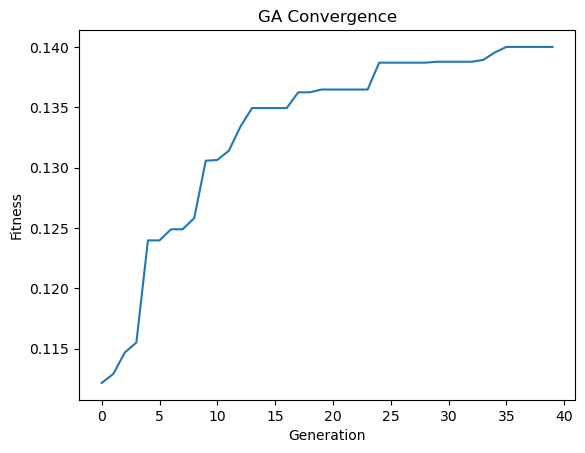

In [55]:

plt.plot(fitness_hist)
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("GA Convergence")
plt.show()


This visualization shows:

- Heatmap → how many times each region is seen (coverage + redundancy)
- Camera positions → where cameras are placed
- Arrows → direction (yaw) of cameras

---

### Why 2D projection?

Even though the problem is 3D:
- Top view (x–y) is easier to interpret
- Shows spatial coverage clearly

---

### What to observe

- Darker regions → higher redundancy  
- White regions → blind spots  
- Arrows → where cameras are looking  

In [56]:
def plot_coverage_heatmap(cams):
    """
    PURPOSE:
    --------
    Visualize coverage as a heatmap along with:
    - camera positions
    - viewing directions (yaw vectors)

    INPUT:
    ------
    cams : array of shape (num_cameras, 5)
           each row = [x, y, z, yaw, pitch]

    OUTPUT:
    -------
    A 2D heatmap (top view) with arrows
    """

    # ---------------------------------------------------------
    # STEP 1: Create 2D grid for visualization (x-y plane)
    # ---------------------------------------------------------
    res = 50  # resolution of heatmap

    x_vals = np.linspace(-10, 10, res)
    y_vals = np.linspace(-10, 10, res)

    heatmap = np.zeros((res, res))

    # ---------------------------------------------------------
    # STEP 2: Compute coverage intensity
    # ---------------------------------------------------------
    # For each grid cell → count how many cameras see it
    for i, x in enumerate(x_vals):
        for j, y in enumerate(y_vals):

            # Fix height (top-down projection)
            z = 1.5  

            count = 0

            for cam in cams:
                if is_visible_3d(cam, [x, y, z]):
                    count += 1

            heatmap[j, i] = count  # note indexing

    # ---------------------------------------------------------
    # STEP 3: Plot heatmap
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))

    plt.imshow(
        heatmap,
        extent=[-10, 10, -10, 10],
        origin='lower'
    )

    plt.colorbar(label="Redundancy (number of views)")

    # ---------------------------------------------------------
    # STEP 4: Plot vehicle boundary
    # ---------------------------------------------------------
    plt.gca().add_patch(
        plt.Rectangle(
            (-vehicle_length/2, -vehicle_width/2),
            vehicle_length,
            vehicle_width,
            fill=False,
            edgecolor='white',
            linewidth=2
        )
    )

    # ---------------------------------------------------------
    # STEP 5: Plot cameras and direction vectors
    # ---------------------------------------------------------
    for cam in cams:
        x, y, z, yaw, pitch = cam

        # Camera position
        plt.scatter(x, y, color='red', s=80)

        # Direction vector (yaw only for top view)
        dx = np.cos(yaw)
        dy = np.sin(yaw)

        plt.arrow(
            x, y,
            dx, dy,
            color='red',
            head_width=0.3,
            length_includes_head=True
        )

    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------
    plt.title("Coverage Heatmap + Camera Positions")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.show()

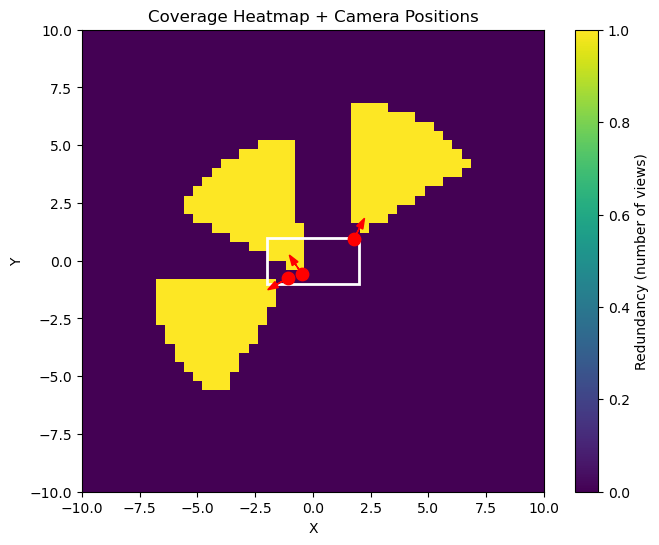

In [57]:
best_cams = solutions[-1]
plot_coverage_heatmap(best_cams)